In [2]:
#Import neccessary library
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


C:\Users\Insha sadaf\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
#read csv
ds = pd.read_csv('./Hospital_readmissions1.csv')

In [3]:
# check the dtype and non null info
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   age                25000 non-null  object
 1   time_in_hospital   25000 non-null  int64 
 2   n_lab_procedures   25000 non-null  int64 
 3   n_procedures       25000 non-null  int64 
 4   n_medications      25000 non-null  int64 
 5   n_outpatient       25000 non-null  int64 
 6   n_inpatient        25000 non-null  int64 
 7   n_emergency        25000 non-null  int64 
 8   medical_specialty  25000 non-null  object
 9   diag_1             25000 non-null  object
 10  diag_2             25000 non-null  object
 11  diag_3             25000 non-null  object
 12  glucose_test       25000 non-null  object
 13  A1Ctest            25000 non-null  object
 14  change             25000 non-null  object
 15  diabetes_med       25000 non-null  object
 16  readmitted         25000 non-null  objec

In [4]:
#check the shape
ds.shape

(25000, 17)

# Understanding Each Columns

1. Age - Age of the patient
2. No of days patient stayed in hospital
3. No of lab test performed during the visit
4. No of surguries done
5. No of medication prescribed
6. No of outpatient visit in past year
7. No of inpatient visit in past year
8. No of emergency visit in the past year
5. Type of doctor or department treated that doctor
6. primary diagnosis category
7. Secondary diagnosis category
8. Third dianosis category
9. glucose test was performed or not
10. Whether HbA1c test was performed
11. medication dosage was changed or not
12. Whether diabetes medication was prescribed
13. whether the patient was readmitted


# DATA WRANGLING


In [5]:
#see top 5 rows
ds.head(5)

,age,time_in_hospital,n_lab_procedures,n_procedures,n_medications,n_outpatient,n_inpatient,n_emergency,medical_specialty,diag_1,diag_2,diag_3,glucose_test,A1Ctest,change,diabetes_med,readmitted
0,[70-80),8,72,1,18,2,0,0,Missing,Circulatory,Respiratory,Other,no,no,no,yes,no
1,[70-80),3,34,2,13,0,0,0,Other,Other,Other,Other,no,no,no,yes,no
2,[50-60),5,45,0,18,0,0,0,Missing,Circulatory,Circulatory,Circulatory,no,no,yes,yes,yes
3,[70-80),2,36,0,12,1,0,0,Missing,Circulatory,Other,Diabetes,no,no,yes,yes,yes
4,[60-70),1,42,0,7,0,0,0,InternalMedicine,Other,Circulatory,Respiratory,no,no,no,yes,no


In [6]:
#check for the non - null value
ds.isnull().sum()

age                  0
time_in_hospital     0
n_lab_procedures     0
n_procedures         0
n_medications        0
n_outpatient         0
n_inpatient          0
n_emergency          0
medical_specialty    0
diag_1               0
diag_2               0
diag_3               0
glucose_test         0
A1Ctest              0
change               0
diabetes_med         0
readmitted           0
dtype: int64

In [7]:
#check for the duplicated value
ds.duplicated().sum()

0

In [8]:
ds.describe()

,time_in_hospital,n_lab_procedures,n_procedures,n_medications,n_outpatient,n_inpatient,n_emergency
count,25000.00000,25000.00000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,4.45332,43.24076,1.352360,16.252400,0.366400,0.615960,0.186600
std,3.00147,19.81862,1.715179,8.060532,1.195478,1.177951,0.885873
min,1.00000,1.00000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,2.00000,31.00000,0.000000,11.000000,0.000000,0.000000,0.000000
50%,4.00000,44.00000,1.000000,15.000000,0.000000,0.000000,0.000000
75%,6.00000,57.00000,2.000000,20.000000,0.000000,1.000000,0.000000
max,14.00000,113.00000,6.000000,79.000000,33.000000,15.000000,64.000000


# Analyze the categorical columns

In [9]:
ds['age'].value_counts()

age
[70-80)     6837
[60-70)     5913
[80-90)     4516
[50-60)     4452
[40-50)     2532
[90-100)     750
Name: count, dtype: int64

In [10]:

ds['medical_specialty'].value_counts()

medical_specialty
Missing                   12382
InternalMedicine           3565
Other                      2664
Emergency/Trauma           1885
Family/GeneralPractice     1882
Cardiology                 1409
Surgery                    1213
Name: count, dtype: int64

In [11]:
# replace misisng with nan
ds['medical_specialty'] = ds['medical_specialty'].replace('Missing',pd.NA)

In [12]:
# fill the nan value with unknown - bcz not not everuone needs speciality
ds['medical_specialty'] = ds['medical_specialty'].fillna("Unknown")

In [13]:
ds['medical_specialty'].value_counts()

medical_specialty
Unknown                   12382
InternalMedicine           3565
Other                      2664
Emergency/Trauma           1885
Family/GeneralPractice     1882
Cardiology                 1409
Surgery                    1213
Name: count, dtype: int64

In [14]:
ds['diag_1'].value_counts()             

diag_1
Circulatory        7824
Other              6498
Respiratory        3680
Digestive          2329
Diabetes           1747
Injury             1666
Musculoskeletal    1252
Missing               4
Name: count, dtype: int64

In [15]:
ds['diag_2'].value_counts()             

diag_2
Other              9056
Circulatory        8134
Diabetes           2906
Respiratory        2872
Digestive           973
Injury              591
Musculoskeletal     426
Missing              42
Name: count, dtype: int64

In [16]:
ds['diag_3'].value_counts()   

diag_3
Other              9107
Circulatory        7686
Diabetes           4261
Respiratory        1915
Digestive           916
Injury              464
Musculoskeletal     455
Missing             196
Name: count, dtype: int64

In [17]:
# replace the missing with nan value
ds[['diag_1','diag_2','diag_3']] = ds[['diag_1','diag_2','diag_3']].replace('Missing',pd.NA)

In [18]:
# fill the nan value with other since in all there diag_1, diag_2, diag_3 it is dominant
ds[['diag_1','diag_2','diag_3']] = ds[['diag_1','diag_2','diag_3']].fillna("Other")

In [19]:
ds['glucose_test'].value_counts()   

glucose_test
no        23625
normal      689
high        686
Name: count, dtype: int64

In [20]:
ds['A1Ctest'].value_counts()  

A1Ctest
no        20938
high       2827
normal     1235
Name: count, dtype: int64

In [21]:
ds['change'].value_counts() 

change
no     13497
yes    11503
Name: count, dtype: int64

In [22]:
ds['diabetes_med'].value_counts()        

diabetes_med
yes    19228
no      5772
Name: count, dtype: int64

In [23]:
ds.head(5)

,age,time_in_hospital,n_lab_procedures,n_procedures,n_medications,n_outpatient,n_inpatient,n_emergency,medical_specialty,diag_1,diag_2,diag_3,glucose_test,A1Ctest,change,diabetes_med,readmitted
0,[70-80),8,72,1,18,2,0,0,Unknown,Circulatory,Respiratory,Other,no,no,no,yes,no
1,[70-80),3,34,2,13,0,0,0,Other,Other,Other,Other,no,no,no,yes,no
2,[50-60),5,45,0,18,0,0,0,Unknown,Circulatory,Circulatory,Circulatory,no,no,yes,yes,yes
3,[70-80),2,36,0,12,1,0,0,Unknown,Circulatory,Other,Diabetes,no,no,yes,yes,yes
4,[60-70),1,42,0,7,0,0,0,InternalMedicine,Other,Circulatory,Respiratory,no,no,no,yes,no


# Analyze the numerical Columns

In [24]:
cols = ['time_in_hospital','n_lab_procedures','n_procedures','n_medications','n_outpatient','n_inpatient','n_emergency']
for col in cols:
    ds[cols] = ds[cols].replace('?/.#$%^', pd.NA)
    ds[cols] = ds[cols].apply(pd.to_numeric, errors='coerce')

In [25]:
ds.head(5)

,age,time_in_hospital,n_lab_procedures,n_procedures,n_medications,n_outpatient,n_inpatient,n_emergency,medical_specialty,diag_1,diag_2,diag_3,glucose_test,A1Ctest,change,diabetes_med,readmitted
0,[70-80),8,72,1,18,2,0,0,Unknown,Circulatory,Respiratory,Other,no,no,no,yes,no
1,[70-80),3,34,2,13,0,0,0,Other,Other,Other,Other,no,no,no,yes,no
2,[50-60),5,45,0,18,0,0,0,Unknown,Circulatory,Circulatory,Circulatory,no,no,yes,yes,yes
3,[70-80),2,36,0,12,1,0,0,Unknown,Circulatory,Other,Diabetes,no,no,yes,yes,yes
4,[60-70),1,42,0,7,0,0,0,InternalMedicine,Other,Circulatory,Respiratory,no,no,no,yes,no


# EDA

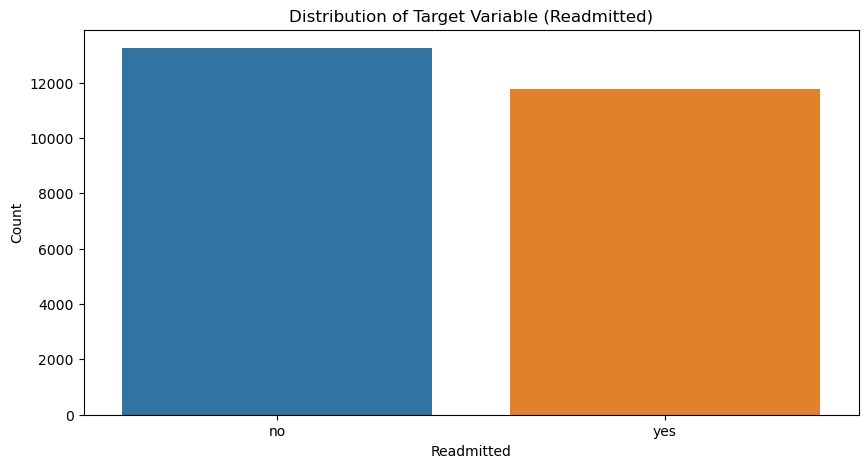

In [26]:
plt.figure(figsize=(10,5))
sns.countplot(x='readmitted', data=ds)
plt.title('Distribution of Target Variable (Readmitted)')
plt.xlabel('Readmitted')
plt.ylabel('Count')
plt.show()

C:\Users\Insha sadaf\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Insha sadaf\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Insha sadaf\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Insha sadaf\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values

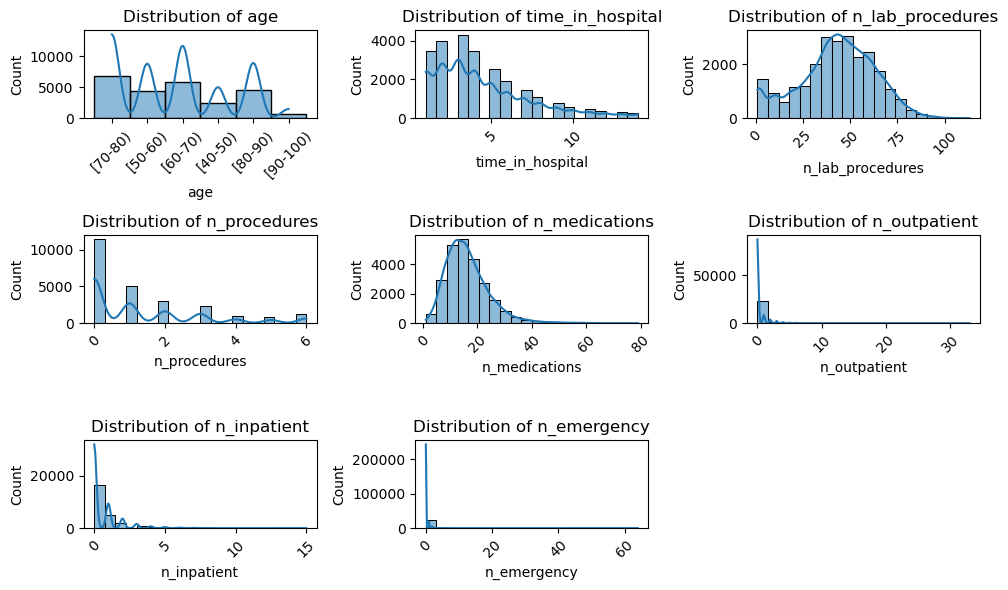

In [27]:
#visualizing cols
cols = ['age','time_in_hospital','n_lab_procedures',
            'n_procedures','n_medications','n_outpatient',
            'n_inpatient','n_emergency']
plt.figure(figsize=(10,6))
for i ,col in enumerate(cols,1):
    plt.subplot(3,3,i)
    sns.histplot(ds[col],kde=True,bins=20)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
    

# Observation
n_inpatient
n_outpatient
n_emergency 
- majority values are zeros for all three

n_medication
n_lab_procedure
- bell shape curve(normal distribution)

Age looks approximately normal

time_in_hospital
- Slightly skewed(right)



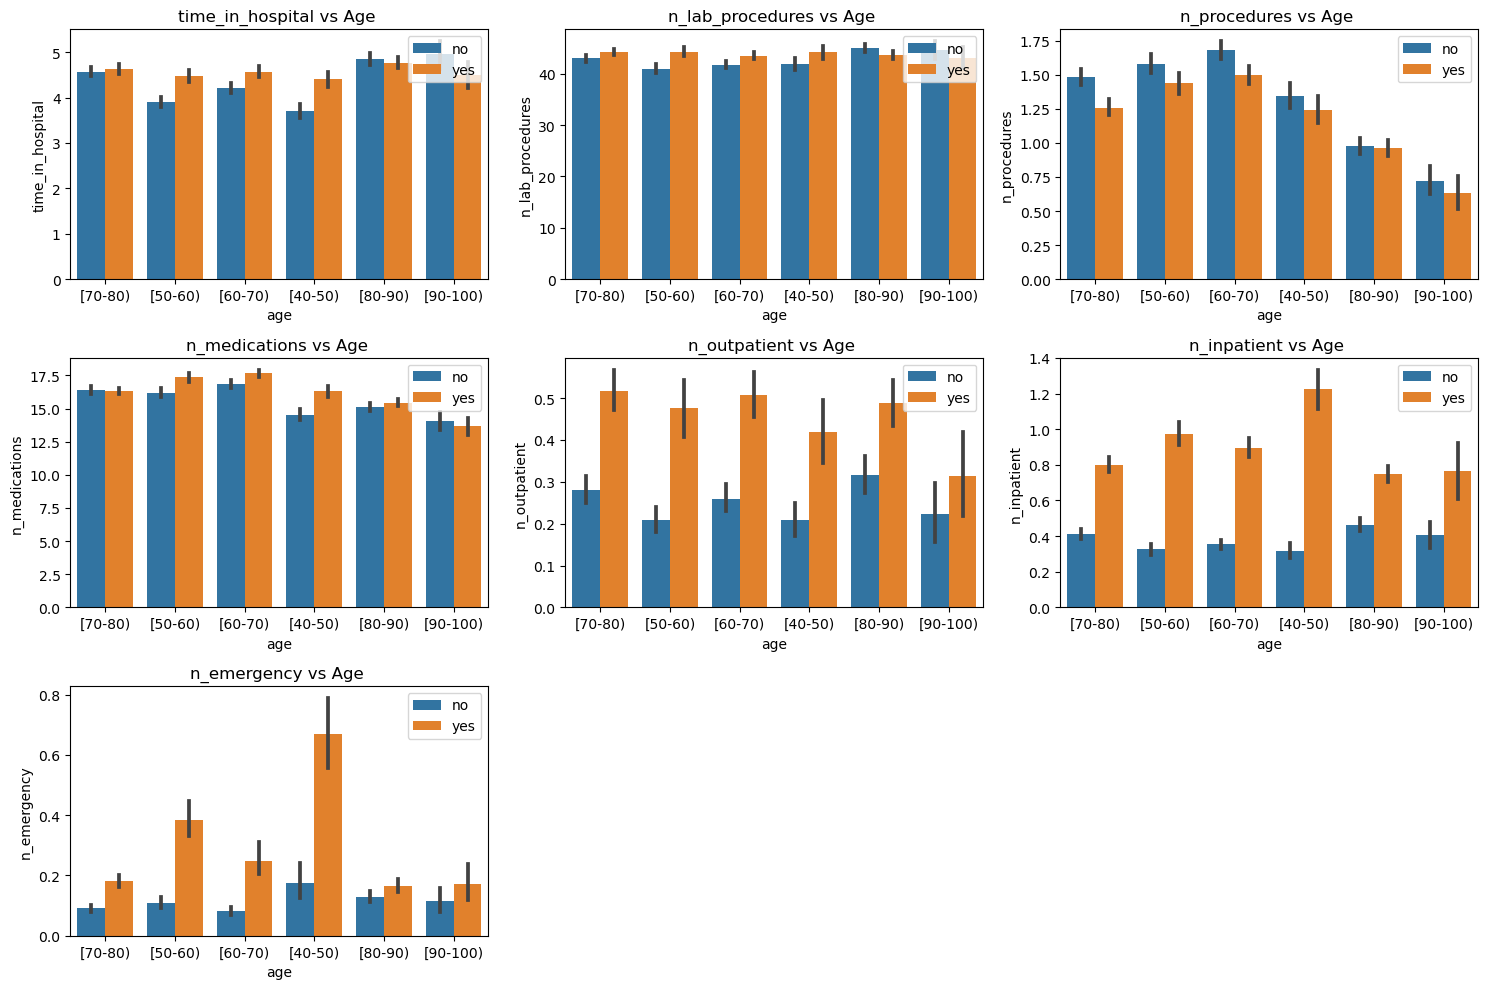

In [28]:
#numerical column vs age hue - target 
num_cols = ['time_in_hospital','n_lab_procedures',
            'n_procedures','n_medications','n_outpatient',
            'n_inpatient','n_emergency']
plt.figure(figsize=(15,10))
for i,col in enumerate(num_cols,1):
    plt.subplot(3,3,i)
    sns.barplot(x='age', y=col,hue = 'readmitted', data=ds)
    plt.title(f'{col} vs Age ')
    plt.legend(loc='upper right')
plt.tight_layout()
plt.show()


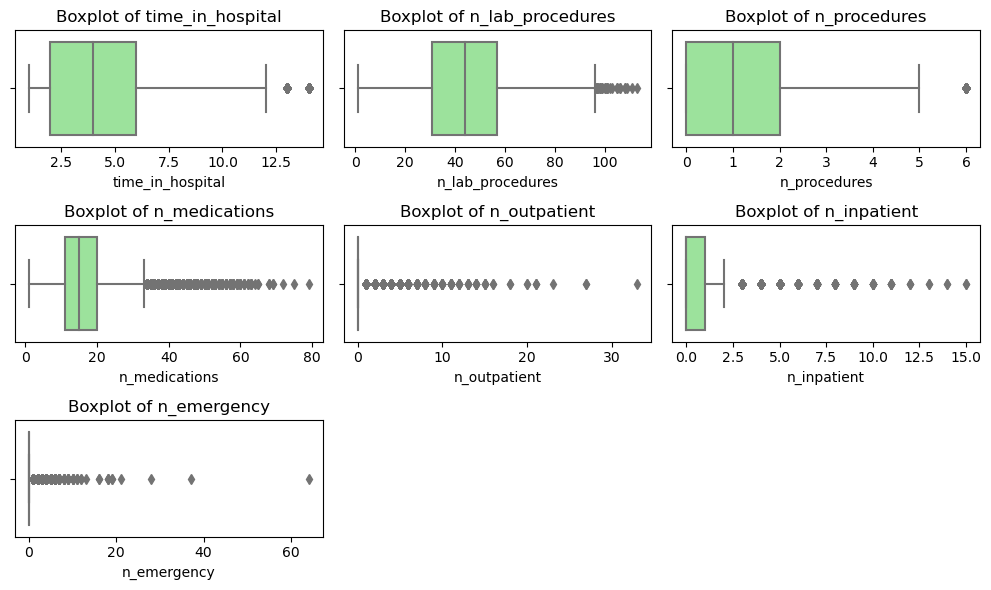

In [29]:
#Boxplot
plt.figure(figsize=(10,6))
for i , col in enumerate(num_cols,1):
    plt.subplot(3,3,i)
    sns.boxplot(x=ds[col],color='Lightgreen')
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

In [30]:
#handle outliers
outlier_col = ['n_lab_procedures','n_procedures','n_medications',
            'n_inpatient','time_in_hospital']
def cap_outliers(ds,outlier_col):
    for col in outlier_col:
        Q1 = ds[col].quantile(0.25)
        Q3 = ds[col].quantile(0.75)
        IQR = Q3-Q1
        lower = Q1-IQR*1.5
        upper = Q3+IQR*1.5
        ds[col] = np.where(ds[col] > upper, upper, np.where(ds[col] < lower, lower, ds[col]))
    return ds
ds=cap_outliers(ds,outlier_col)

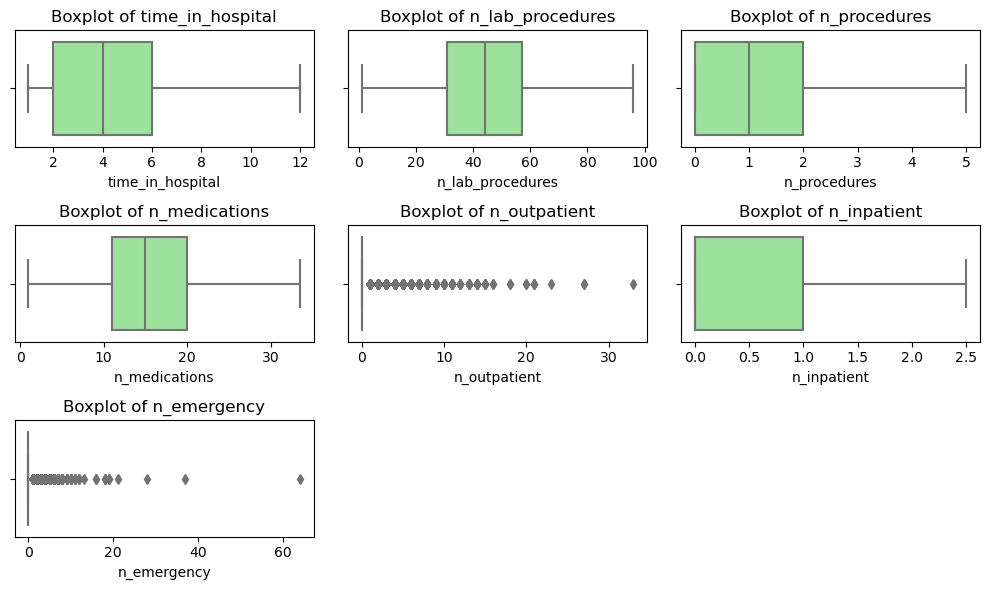

In [31]:
#Boxplot
plt.figure(figsize=(10,6))
for i , col in enumerate(num_cols,1):
    plt.subplot(3,3,i)
    sns.boxplot(x=ds[col],color='Lightgreen')
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

n_procedures vs readmission
n_inpatient vs readmission 
- Here lower bound go below zero and since count cannot go below zero that why is indicating zero

In [32]:
#log transformation to sparse columns(used to deal with data that is highly skewed)
ds['n_outpatient']=np.log1p(ds['n_outpatient'])
ds['n_emergency']=np.log1p(ds['n_emergency'])

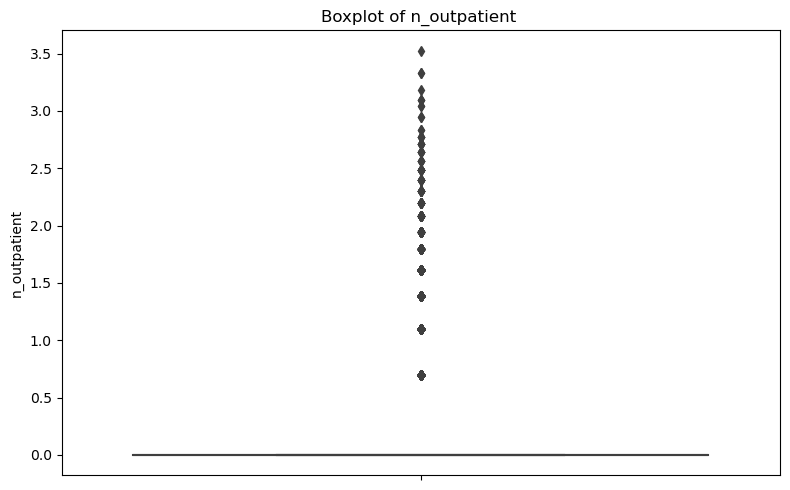

In [33]:
plt.figure(figsize=(8,5))
sns.boxplot(data=ds,y='n_outpatient')
plt.title(f'Boxplot of n_outpatient ')
plt.tight_layout()
plt.show()

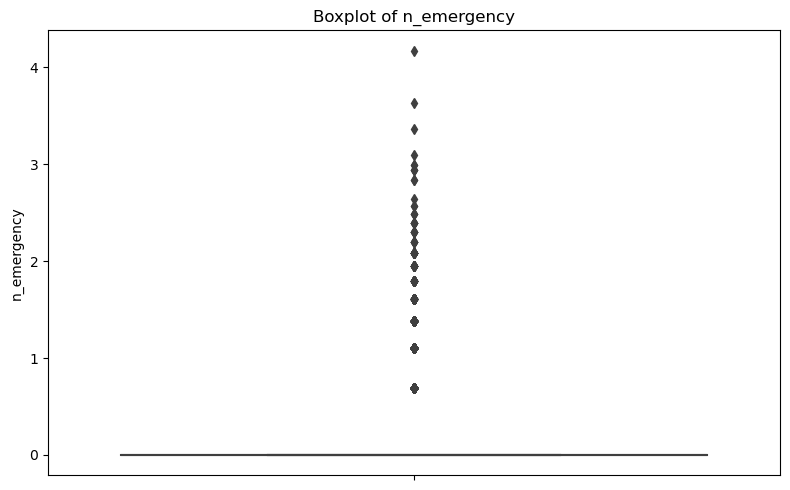

In [34]:
plt.figure(figsize=(8,5))
sns.boxplot(data=ds,y='n_emergency')
plt.title(f'Boxplot of n_emergency')
plt.tight_layout()
plt.show()

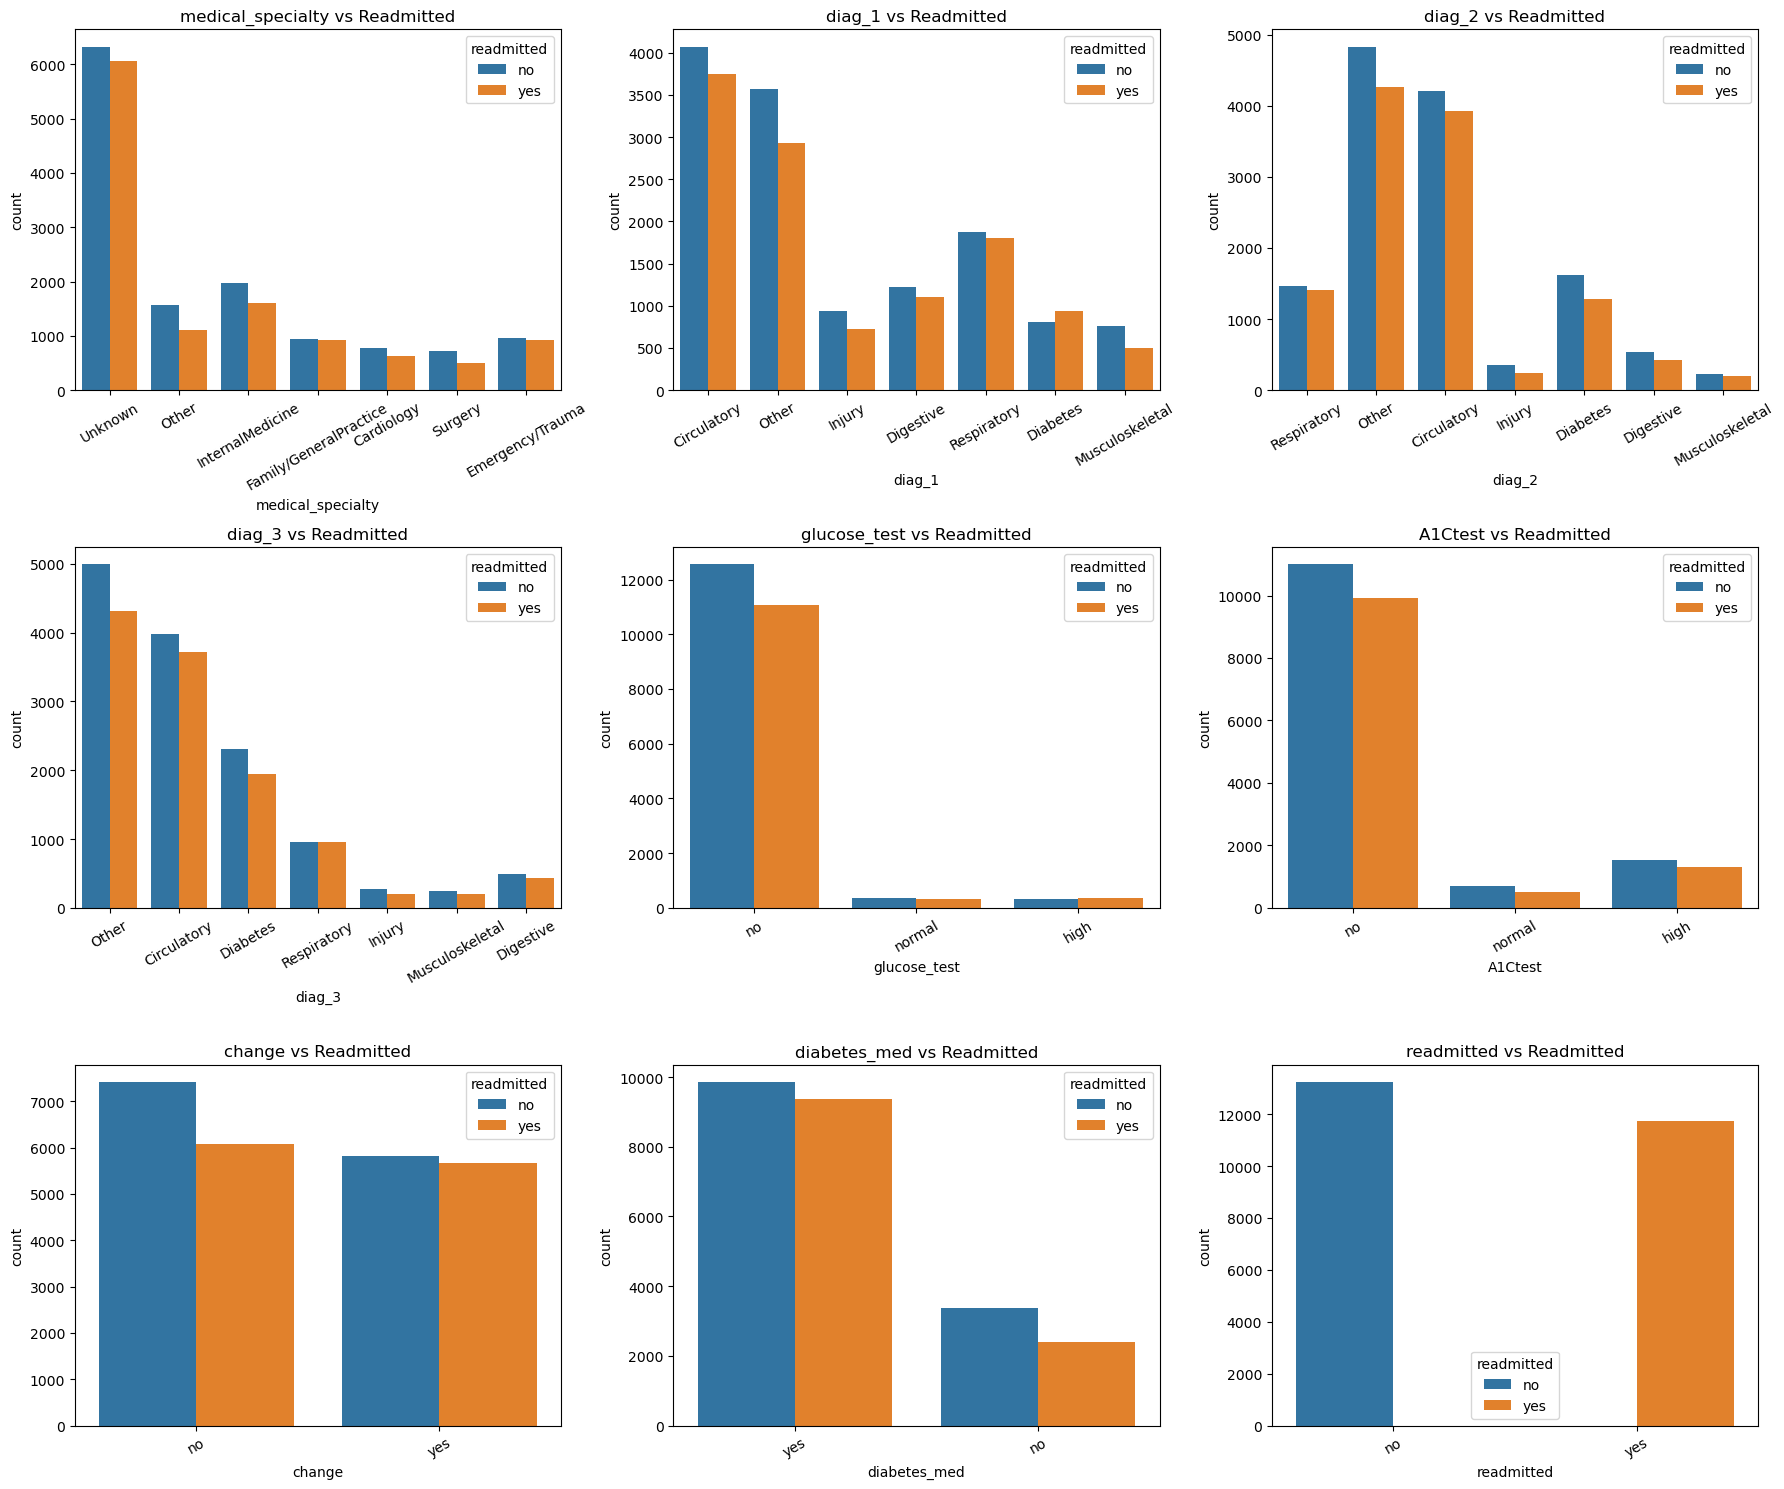

In [35]:
cat_cols = ['medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'glucose_test',
            'A1Ctest', 'change', 'diabetes_med', 'readmitted']
#countplot
plt.figure(figsize=(18,15))
for i ,col in enumerate(cat_cols,1):
    plt.subplot(3,3,i)
    sns.countplot(x=col,hue = 'readmitted',data=ds) 
    plt.title(f'{col} vs Readmitted')
    plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Feature Engineering


In [36]:
#handling skewed numerical data 
# 1- if patient had visit
# 0- if patient donot had visit
# ds['n_outpatient']= np.where(ds['n_outpatient']>0,1,0)
# ds['n_inpatient']= np.where(ds['n_inpatient']>0,1,0)
# ds['n_emergency']= np.where(ds['n_emergency']>0,1,0)

ds['Total_visit'] =ds['n_outpatient']+ds['n_inpatient']+ds['n_emergency']

In [37]:
ds['med_per_day']=ds['n_medications']/ds['time_in_hospital']
ds['labs_per_day'] = ds['n_lab_procedures']/ds['time_in_hospital']
ds['procedures_per_day'] = ds['n_procedures']/ds['time_in_hospital']

In [38]:
ds['readmitted'] = ds['readmitted'].apply(lambda x: 1 if x == 'yes' else 0)
ds['change'] = ds['change'].apply(lambda x: 1 if x == 'yes' else 0)
ds['diabetes_med']= ds['diabetes_med'].apply(lambda x:1 if x=='yes'else 0)

In [39]:
ds.head(5)

,age,time_in_hospital,n_lab_procedures,n_procedures,n_medications,n_outpatient,n_inpatient,n_emergency,medical_specialty,diag_1,...,diag_3,glucose_test,A1Ctest,change,diabetes_med,readmitted,Total_visit,med_per_day,labs_per_day,procedures_per_day
0,[70-80),8.0,72.0,1.0,18.0,1.098612,0.0,0.0,Unknown,Circulatory,...,Other,no,no,0,1,0,1.098612,2.250000,9.000000,0.125000
1,[70-80),3.0,34.0,2.0,13.0,0.000000,0.0,0.0,Other,Other,...,Other,no,no,0,1,0,0.000000,4.333333,11.333333,0.666667
2,[50-60),5.0,45.0,0.0,18.0,0.000000,0.0,0.0,Unknown,Circulatory,...,Circulatory,no,no,1,1,1,0.000000,3.600000,9.000000,0.000000
3,[70-80),2.0,36.0,0.0,12.0,0.693147,0.0,0.0,Unknown,Circulatory,...,Diabetes,no,no,1,1,1,0.693147,6.000000,18.000000,0.000000
4,[60-70),1.0,42.0,0.0,7.0,0.000000,0.0,0.0,InternalMedicine,Other,...,Respiratory,no,no,0,1,0,0.000000,7.000000,42.000000,0.000000


In [40]:
ds['age'].value_counts()

age
[70-80)     6837
[60-70)     5913
[80-90)     4516
[50-60)     4452
[40-50)     2532
[90-100)     750
Name: count, dtype: int64

In [41]:
age_mapping={
    '[40-50)':0,
    '[50-60)':1,
    '[60-70)':2,
    '[70-80)':3,
    '[80-90)':4,
    '[90-100)':5
    
}
ds['age_encoded']=ds['age'].map(age_mapping)
ds.head(10)

,age,time_in_hospital,n_lab_procedures,n_procedures,n_medications,n_outpatient,n_inpatient,n_emergency,medical_specialty,diag_1,...,glucose_test,A1Ctest,change,diabetes_med,readmitted,Total_visit,med_per_day,labs_per_day,procedures_per_day,age_encoded
0,[70-80),8.0,72.0,1.0,18.0,1.098612,0.0,0.000000,Unknown,Circulatory,...,no,no,0,1,0,1.098612,2.250000,9.000000,0.125000,3
1,[70-80),3.0,34.0,2.0,13.0,0.000000,0.0,0.000000,Other,Other,...,no,no,0,1,0,0.000000,4.333333,11.333333,0.666667,3
2,[50-60),5.0,45.0,0.0,18.0,0.000000,0.0,0.000000,Unknown,Circulatory,...,no,no,1,1,1,0.000000,3.600000,9.000000,0.000000,1
3,[70-80),2.0,36.0,0.0,12.0,0.693147,0.0,0.000000,Unknown,Circulatory,...,no,no,1,1,1,0.693147,6.000000,18.000000,0.000000,3
4,[60-70),1.0,42.0,0.0,7.0,0.000000,0.0,0.000000,InternalMedicine,Other,...,no,no,0,1,0,0.000000,7.000000,42.000000,0.000000,2
5,[40-50),2.0,51.0,0.0,10.0,0.000000,0.0,0.000000,Unknown,Other,...,no,no,0,0,1,0.000000,5.000000,25.500000,0.000000,0
6,[50-60),4.0,44.0,2.0,21.0,0.000000,0.0,0.000000,Unknown,Injury,...,no,normal,1,1,0,0.000000,5.250000,11.000000,0.500000,1
7,[60-70),1.0,19.0,5.0,16.0,0.000000,0.0,0.693147,Other,Circulatory,...,no,no,0,1,1,0.693147,16.000000,19.000000,5.000000,2
8,[80-90),4.0,67.0,3.0,13.0,0.000000,0.0,0.000000,InternalMedicine,Digestive,...,no,no,0,0,1,0.000000,3.250000,16.750000,0.750000,4
9,[70-80),8.0,37.0,1.0,18.0,0.000000,0.0,0.000000,Family/GeneralPractice,Respiratory,...,no,no,1,1,0,0.000000,2.250000,4.625000,0.125000,3


In [42]:
ds=ds.drop('age',axis =1)

In [43]:
cat_cols = ['medical_specialty', 'diag_1', 'diag_2', 'diag_3', 
                              'glucose_test', 'A1Ctest']
ds= pd.get_dummies(ds,columns=cat_cols,drop_first = True)

In [44]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 43 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   time_in_hospital                          25000 non-null  float64
 1   n_lab_procedures                          25000 non-null  float64
 2   n_procedures                              25000 non-null  float64
 3   n_medications                             25000 non-null  float64
 4   n_outpatient                              25000 non-null  float64
 5   n_inpatient                               25000 non-null  float64
 6   n_emergency                               25000 non-null  float64
 7   change                                    25000 non-null  int64  
 8   diabetes_med                              25000 non-null  int64  
 9   readmitted                                25000 non-null  int64  
 10  Total_visit                       

In [45]:
bool_cols = ds.select_dtypes(include=['bool']).columns
ds[bool_cols] = ds[bool_cols].astype(int)
print(ds.head(5))

   time_in_hospital  n_lab_procedures  n_procedures  n_medications  \
0               8.0              72.0           1.0           18.0   
1               3.0              34.0           2.0           13.0   
2               5.0              45.0           0.0           18.0   
3               2.0              36.0           0.0           12.0   
4               1.0              42.0           0.0            7.0   

   n_outpatient  n_inpatient  n_emergency  change  diabetes_med  readmitted  \
0      1.098612          0.0          0.0       0             1           0   
1      0.000000          0.0          0.0       0             1           0   
2      0.000000          0.0          0.0       1             1           1   
3      0.693147          0.0          0.0       1             1           1   
4      0.000000          0.0          0.0       0             1           0   

   ...  diag_3_Diabetes  diag_3_Digestive  diag_3_Injury  \
0  ...                0                 0   

In [46]:
X = ds.drop('readmitted',axis=1)
y=ds['readmitted']
X

,time_in_hospital,n_lab_procedures,n_procedures,n_medications,n_outpatient,n_inpatient,n_emergency,change,diabetes_med,Total_visit,...,diag_3_Diabetes,diag_3_Digestive,diag_3_Injury,diag_3_Musculoskeletal,diag_3_Other,diag_3_Respiratory,glucose_test_no,glucose_test_normal,A1Ctest_no,A1Ctest_normal
0,8.0,72.0,1.0,18.0,1.098612,0.0,0.0,0,1,1.098612,...,0,0,0,0,1,0,1,0,1,0
1,3.0,34.0,2.0,13.0,0.000000,0.0,0.0,0,1,0.000000,...,0,0,0,0,1,0,1,0,1,0
2,5.0,45.0,0.0,18.0,0.000000,0.0,0.0,1,1,0.000000,...,0,0,0,0,0,0,1,0,1,0
3,2.0,36.0,0.0,12.0,0.693147,0.0,0.0,1,1,0.693147,...,1,0,0,0,0,0,1,0,1,0
4,1.0,42.0,0.0,7.0,0.000000,0.0,0.0,0,1,0.000000,...,0,0,0,0,0,1,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,12.0,77.0,1.0,30.0,0.000000,0.0,0.0,0,0,0.000000,...,0,0,0,0,0,0,1,0,0,1
24996,2.0,66.0,0.0,24.0,0.000000,0.0,0.0,1,1,0.000000,...,0,0,0,0,1,0,1,0,0,0
24997,5.0,12.0,0.0,6.0,0.000000,1.0,0.0,0,0,1.000000,...,0,0,0,0,1,0,0,1,1,0
24998,2.0,61.0,3.0,15.0,0.000000,0.0,0.0,1,1,0.000000,...,0,0,0,0,1,0,1,0,1,0


In [47]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [48]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
numerical_cols = ['time_in_hospital', 'n_lab_procedures', 'n_procedures',
                  'n_medications', 'n_outpatient', 'n_inpatient', 
                  'n_emergency', 'age_encoded','Total_visit',
                  'med_per_day','labs_per_day','procedures_per_day']

X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

In [49]:
print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (20000, 42)
Testing Shape: (5000, 42)


In [50]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

In [51]:
knn = KNeighborsClassifier(n_neighbors = 3)
rfc = RandomForestClassifier(n_estimators = 200, max_depth = 10,criterion = 'gini',
                             random_state = 7)
svc = SVC()
lc = LogisticRegression(max_iter=1000)


In [52]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

In [53]:
for clf in (knn,rfc,svc,lc):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    print("Accuracy score of ",clf.__class__.__name__,
         "=",accuracy_score(y_test,y_pred)*100)

Accuracy score of  KNeighborsClassifier = 55.42
Accuracy score of  RandomForestClassifier = 61.3
Accuracy score of  SVC = 61.68
Accuracy score of  LogisticRegression = 61.5


In [54]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.61      0.77      0.68      2649
           1       0.63      0.44      0.52      2351

    accuracy                           0.61      5000
   macro avg       0.62      0.61      0.60      5000
weighted avg       0.62      0.61      0.60      5000



In [61]:
feature_importances = pd.DataFrame(rfc.feature_importances_,
                                   index = X_train.columns,
                                   columns=['importance']).sort_values('importance', ascending=False)
print(feature_importances)

                                          importance
Total_visit                                 0.177877
n_inpatient                                 0.126303
labs_per_day                                0.067645
n_medications                               0.066206
n_lab_procedures                            0.063834
med_per_day                                 0.062579
procedures_per_day                          0.044332
age_encoded                                 0.042853
n_outpatient                                0.041460
n_emergency                                 0.034524
time_in_hospital                            0.032620
n_procedures                                0.023714
diabetes_med                                0.017527
diag_2_Other                                0.010116
diag_1_Other                                0.010093
diag_3_Other                                0.010022
change                                      0.009541
medical_specialty_Unknown                   0.